# **Classification Multi-classe de Radiographies Pulmonaires avec Xception**

**Auteurs :** Keita Hadiatou & Rouchdi Asmaa  
**Date :** Novembre 2025  
**Objectif :** Développer un modèle de Deep Learning pour classifier des radiographies pulmonaires en trois catégories : COVID-19, Pneumonie, et Normal.

---

## **Contexte du projet**

La COVID-19 présente des symptômes radiologiques similaires à d'autres pneumonies. Un diagnostic rapide et précis par imagerie est essentiel pour :
- Le triage des patients
- Le contrôle de l'infection
- L'optimisation des ressources médicales

**Solution proposée :** Utilisation du modèle Xception avec Transfer Learning pour une classification automatique.

---

## **Objectifs pédagogiques**
1. Maîtriser le Transfer Learning avec Xception
2. Gérer un dataset médical déséquilibré
3. Implémenter des techniques d'augmentation de données
4. Évaluer un modèle avec des métriques médicales appropriées
5. Visualiser et interpréter les résultats

---

## **Étape 1 : Installation et Import des Bibliothèques**

Nous allons importer toutes les bibliothèques nécessaires pour :
- La manipulation de données (NumPy, Pandas)
- Le traitement d'images (PIL, OpenCV)
- Le Deep Learning (TensorFlow/Keras)
- La visualisation (Matplotlib, Seaborn)
- L'évaluation (Scikit-learn)

In [1]:
# Import des bibliothèques principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Import pour l'évaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.preprocessing import label_binarize

# Configuration pour la reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Vérification GPU
print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))
print("Nombre de GPUs:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Nombre de GPUs: 1


## **Étape 2 : Téléchargement et Exploration du Dataset**

### **2.1 Téléchargement depuis Kaggle**

Le dataset **COVID-19 Radiography Database** contient des radiographies pulmonaires classées en plusieurs catégories.

**Instructions :**
1. Créer un compte Kaggle si nécessaire
2. Obtenir votre API token (Account → Create New API Token)
3. Uploader le fichier `kaggle.json` dans Colab

In [2]:
# Configuration Kaggle API (décommenter si nécessaire)
# from google.colab import files
# files.upload()  # Upload kaggle.json

# Installation des credentials Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Téléchargement du dataset
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database
!unzip -q covid19-radiography-database.zip -d ./dataset

print("✓ Dataset téléchargé et extrait avec succès")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
100% 776M/778M [00:35<00:00, 23.6MB/s]
100% 778M/778M [00:35<00:00, 22.8MB/s]
✓ Dataset téléchargé et extrait avec succès


### **2.2 Exploration de la Structure du Dataset**

Structure du dataset:
✓ COVID               :  3616 images
✓ Normal              : 10192 images
✓ Viral Pneumonia     :  1345 images
Total d'images: 15153


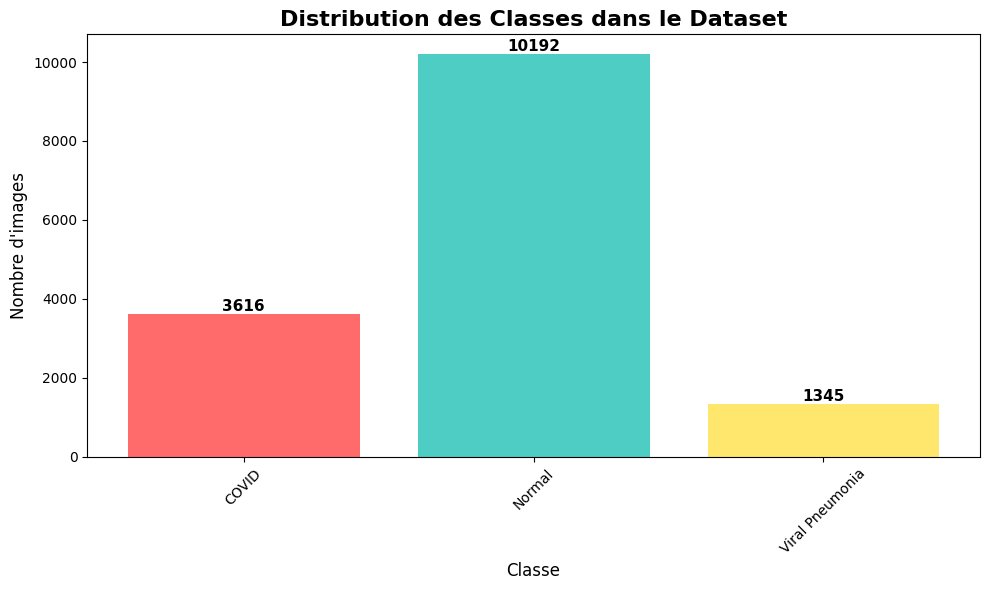


⚠️ Ratio de déséquilibre: 7.58:1
→ Nécessité d'utiliser des poids de classe (class weights)


In [3]:
# Définition des chemins
BASE_DIR = './dataset/COVID-19_Radiography_Dataset'
CLASSES = ['COVID', 'Normal', 'Viral Pneumonia']

# Exploration de la structure
print("Structure du dataset:")
print("=" * 50)

class_counts = {}
for class_name in CLASSES:
    class_path = os.path.join(BASE_DIR, class_name, 'images')
    if os.path.exists(class_path):
        count = len(os.listdir(class_path))
        class_counts[class_name] = count
        print(f"✓ {class_name:20s}: {count:5d} images")
    else:
        print(f"✗ Dossier non trouvé: {class_path}")

total_images = sum(class_counts.values())
print("=" * 50)
print(f"Total d'images: {total_images}")

# Visualisation de la distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=['#FF6B6B', '#4ECDC4', '#FFE66D'])
plt.title('Distribution des Classes dans le Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Nombre d\'images', fontsize=12)
plt.xticks(rotation=45)

# Ajout des valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Calcul du déséquilibre
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count
print(f"\n⚠️ Ratio de déséquilibre: {imbalance_ratio:.2f}:1")
print("→ Nécessité d'utiliser des poids de classe (class weights)")

### **2.3 Visualisation d'Échantillons**

Affichons quelques exemples de chaque classe pour comprendre les caractéristiques visuelles.

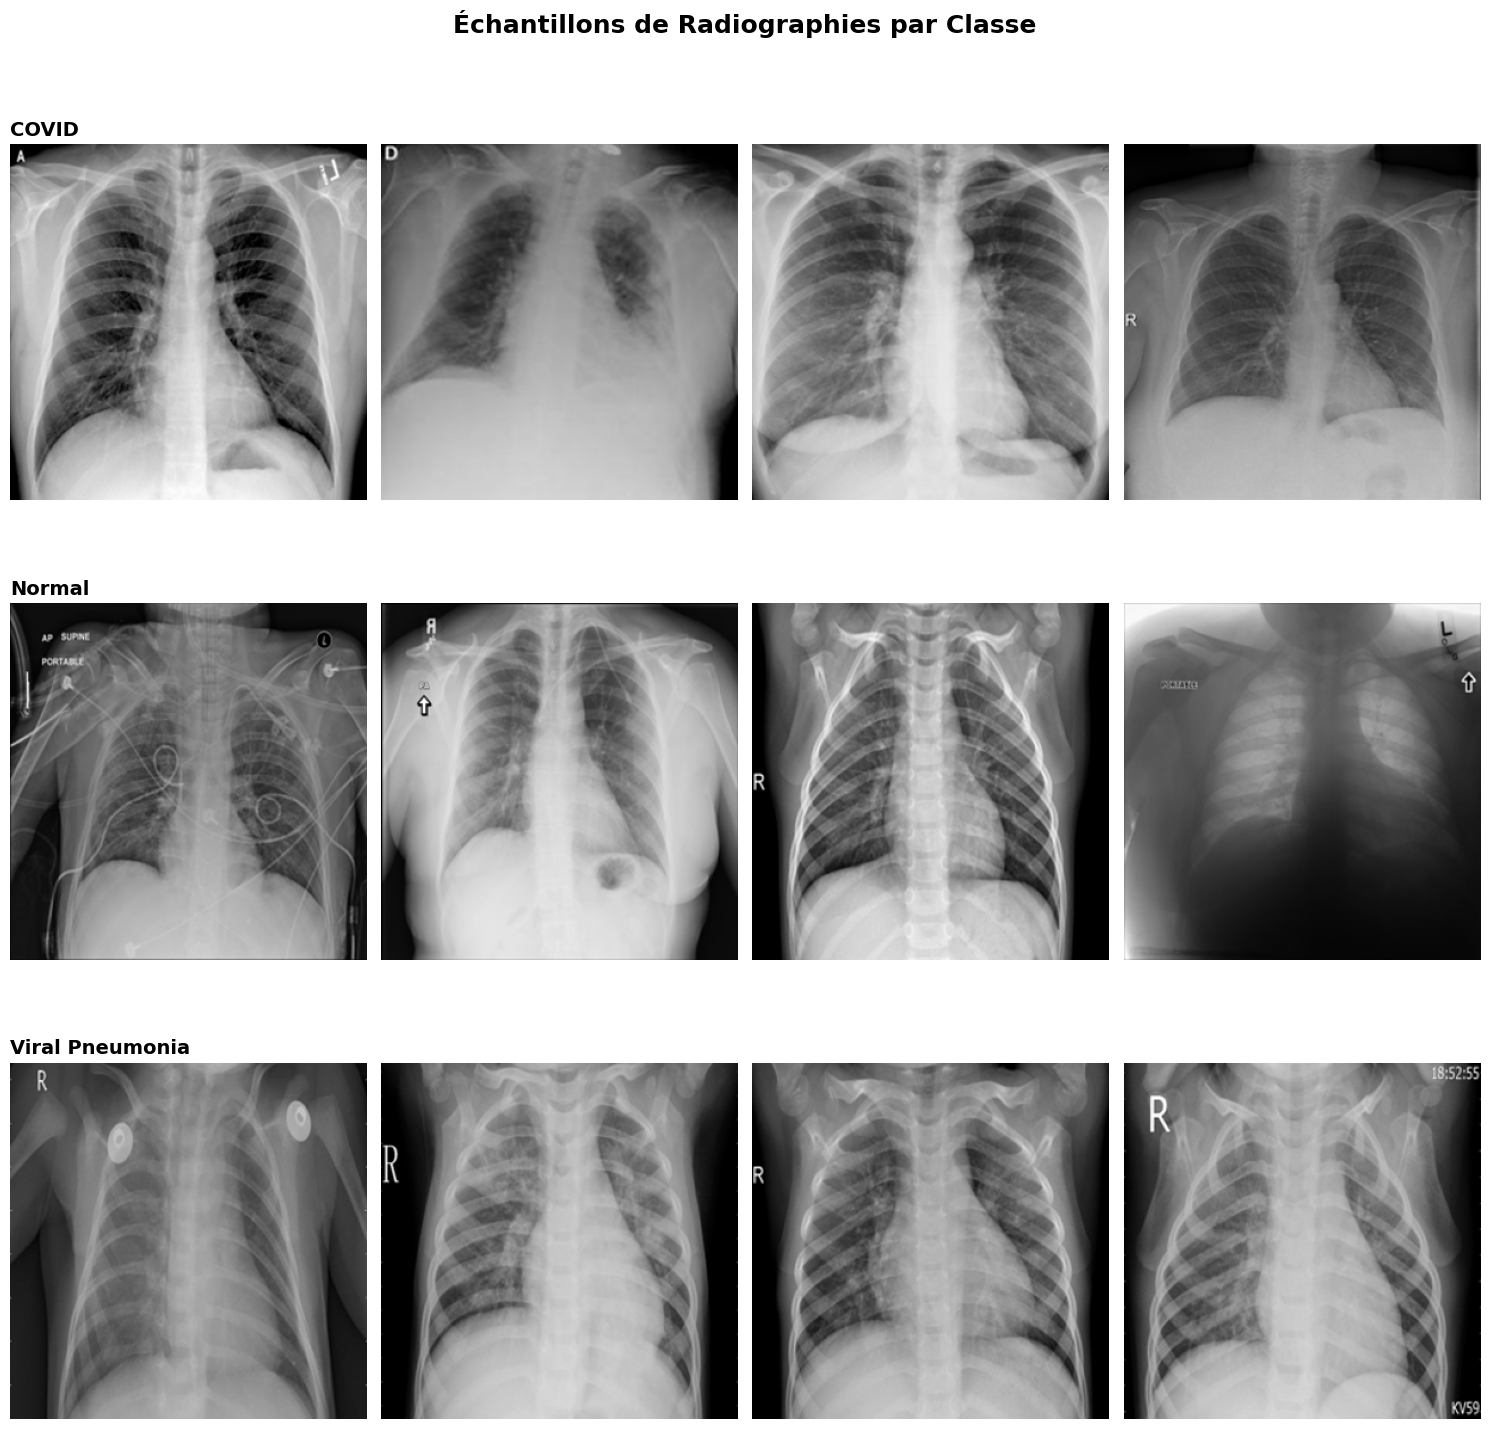

In [4]:
# Fonction pour afficher des échantillons
def display_samples(base_dir, classes, samples_per_class=3):
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(15, 5*len(classes)))
    fig.suptitle('Échantillons de Radiographies par Classe', fontsize=18, fontweight='bold', y=1.00)

    for i, class_name in enumerate(classes):
        class_path = os.path.join(base_dir, class_name, 'images')
        images = os.listdir(class_path)[:samples_per_class]

        for j, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            img = load_img(img_path, target_size=(299, 299))

            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.imshow(img, cmap='gray')
            ax.axis('off')
            if j == 0:
                ax.set_title(f'{class_name}', fontsize=14, fontweight='bold', loc='left')

    plt.tight_layout()
    plt.show()

# Affichage des échantillons
display_samples(BASE_DIR, CLASSES, samples_per_class=4)

## **Étape 3 : Préparation des Données**

### **3.1 Organisation du Dataset**

Nous allons :
1. Diviser les données en ensembles Train/Validation/Test (70%/15%/15%)
2. Réorganiser les fichiers dans une structure appropriée
3. Calculer les poids de classe pour gérer le déséquilibre

In [5]:
import shutil
from sklearn.model_selection import train_test_split

# Création de la structure de dossiers
ORGANIZED_DIR = './dataset_organized'
splits = ['train', 'validation', 'test']

for split in splits:
    for class_name in CLASSES:
        os.makedirs(os.path.join(ORGANIZED_DIR, split, class_name), exist_ok=True)

print("Structure de dossiers créée:")
print(f"📁 {ORGANIZED_DIR}/")
for split in splits:
    print(f"  ├── 📁 {split}/")
    for i, class_name in enumerate(CLASSES):
        prefix = "  │   └──" if i == len(CLASSES)-1 else "  │   ├──"
        print(f"{prefix} 📁 {class_name}/")

# Organisation des fichiers
print("\nOrganisation des fichiers...")
split_info = {'train': [], 'validation': [], 'test': []}

for class_name in CLASSES:
    source_dir = os.path.join(BASE_DIR, class_name, 'images')
    images = [f for f in os.listdir(source_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

    # Split 70-15-15
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=SEED)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=SEED)

    splits_dict = {'train': train_imgs, 'validation': val_imgs, 'test': test_imgs}

    for split, imgs in splits_dict.items():
        split_info[split].append(len(imgs))
        dest_dir = os.path.join(ORGANIZED_DIR, split, class_name)

        for img in imgs:
            src = os.path.join(source_dir, img)
            dst = os.path.join(dest_dir, img)
            shutil.copy2(src, dst)

    print(f"✓ {class_name:20s}: Train={len(train_imgs):4d} | Val={len(val_imgs):4d} | Test={len(test_imgs):4d}")

print("\n✓ Organisation terminée avec succès!")

Structure de dossiers créée:
📁 ./dataset_organized/
  ├── 📁 train/
  │   ├── 📁 COVID/
  │   ├── 📁 Normal/
  │   └── 📁 Viral Pneumonia/
  ├── 📁 validation/
  │   ├── 📁 COVID/
  │   ├── 📁 Normal/
  │   └── 📁 Viral Pneumonia/
  ├── 📁 test/
  │   ├── 📁 COVID/
  │   ├── 📁 Normal/
  │   └── 📁 Viral Pneumonia/

Organisation des fichiers...
✓ COVID               : Train=2531 | Val= 542 | Test= 543
✓ Normal              : Train=7134 | Val=1529 | Test=1529
✓ Viral Pneumonia     : Train= 941 | Val= 202 | Test= 202

✓ Organisation terminée avec succès!


### **3.2 Calcul des Poids de Classe**

Pour gérer le déséquilibre, nous calculons des poids inversement proportionnels à la fréquence des classes.

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# Comptage des images par classe dans l'ensemble d'entraînement
train_dir = os.path.join(ORGANIZED_DIR, 'train')
class_samples = {}

for i, class_name in enumerate(CLASSES):
    class_path = os.path.join(train_dir, class_name)
    count = len(os.listdir(class_path))
    class_samples[i] = count

# Calcul des poids
total_samples = sum(class_samples.values())
class_weights = {i: total_samples / (len(CLASSES) * count)
                 for i, count in class_samples.items()}

print("Poids de classe calculés:")
print("=" * 50)
for i, class_name in enumerate(CLASSES):
    print(f"{class_name:20s}: {class_weights[i]:.4f} (n={class_samples[i]:4d})")
print("=" * 50)
print("\n💡 Ces poids seront utilisés pendant l'entraînement")
print("   pour donner plus d'importance aux classes minoritaires.")

Poids de classe calculés:
COVID               : 1.3968 (n=2531)
Normal              : 0.4956 (n=7134)
Viral Pneumonia     : 3.7570 (n= 941)

💡 Ces poids seront utilisés pendant l'entraînement
   pour donner plus d'importance aux classes minoritaires.


## **Étape 4 : Configuration des Générateurs de Données**

### **4.1 Augmentation de Données (Data Augmentation)**

Pour améliorer la robustesse du modèle, nous appliquons des transformations aléatoires :
- **Rotations** : ±15°
- **Translations** : 10% horizontal et vertical
- **Zoom** : ±10%
- **Shear** : 10%
- **Flip horizontal** : Oui

Ces transformations simulent les variations naturelles des radiographies.

In [7]:
# Paramètres
IMG_SIZE = (299, 299)  # Taille d'entrée pour Xception
BATCH_SIZE = 32

# Générateur pour l'entraînement avec augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Générateurs pour validation et test (sans augmentation)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Création des générateurs
train_generator = train_datagen.flow_from_directory(
    os.path.join(ORGANIZED_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

validation_generator = val_test_datagen.flow_from_directory(
    os.path.join(ORGANIZED_DIR, 'validation'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(ORGANIZED_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n✓ Générateurs de données créés:")
print(f"  • Train:      {train_generator.samples:5d} images")
print(f"  • Validation: {validation_generator.samples:5d} images")
print(f"  • Test:       {test_generator.samples:5d} images")
print(f"\nClasses: {list(train_generator.class_indices.keys())}")

Found 10606 images belonging to 3 classes.
Found 2273 images belonging to 3 classes.
Found 2274 images belonging to 3 classes.

✓ Générateurs de données créés:
  • Train:      10606 images
  • Validation:  2273 images
  • Test:        2274 images

Classes: ['COVID', 'Normal', 'Viral Pneumonia']


### **4.2 Visualisation de l'Augmentation**

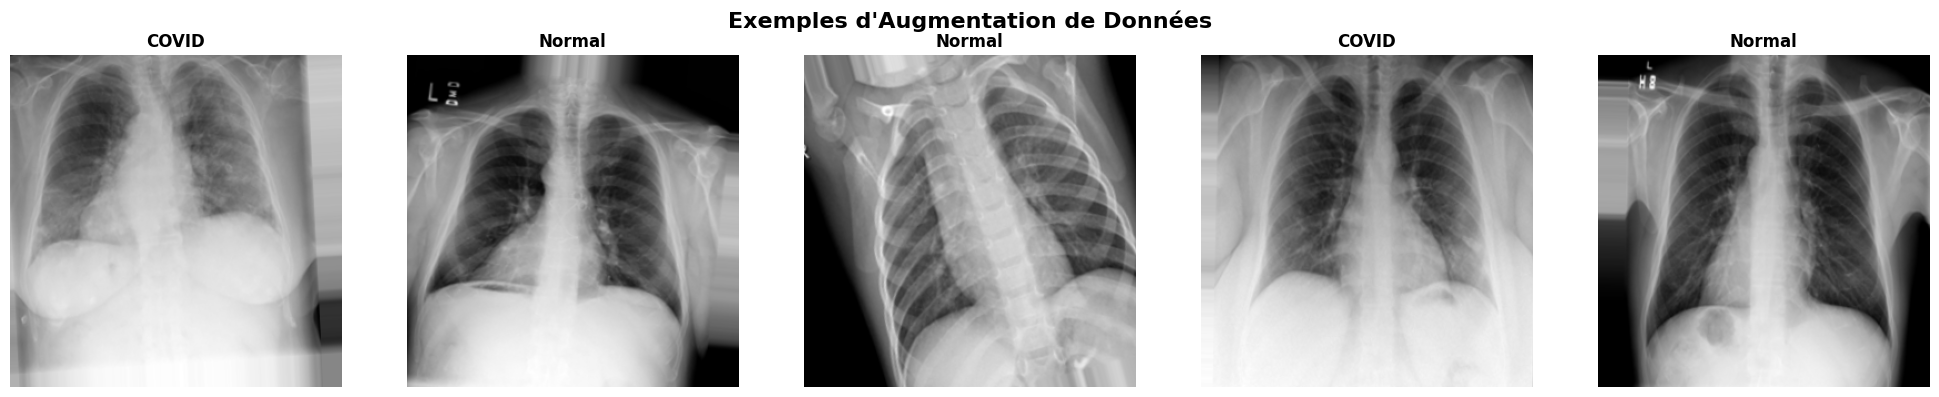

In [8]:
# Fonction pour visualiser l'augmentation
def visualize_augmentation(generator, num_images=5):
    # Récupérer un batch
    images, labels = next(generator)

    fig, axes = plt.subplots(1, num_images, figsize=(20, 4))
    fig.suptitle('Exemples d\'Augmentation de Données', fontsize=16, fontweight='bold')

    for i in range(num_images):
        # Dénormalisation pour l'affichage
        img = images[i]
        img = (img - img.min()) / (img.max() - img.min())

        axes[i].imshow(img)
        axes[i].axis('off')
        class_idx = np.argmax(labels[i])
        class_name = list(generator.class_indices.keys())[class_idx]
        axes[i].set_title(class_name, fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Visualisation
visualize_augmentation(train_generator, num_images=5)

## **Étape 5 : Construction du Modèle Xception avec Transfer Learning**

### **5.1 Architecture Xception**

**Xception** (Extreme Inception) est une architecture basée sur des convolutions séparables en profondeur.

**Avantages :**
- Meilleure efficacité paramétrique
- Performance supérieure sur l'imagerie médicale
- Pré-entraîné sur ImageNet (1.4M images)

**Notre stratégie :**
1. Charger Xception pré-entraîné (sans la couche de classification)
2. Geler les couches de base initialement
3. Ajouter des couches personnalisées pour notre tâche
4. Fine-tuning progressif

In [9]:
def build_xception_model(num_classes=3, img_size=(299, 299, 3)):
    """
    Construit le modèle Xception avec Transfer Learning
    """
    # Chargement du modèle de base Xception
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=img_size
    )

    # Geler les couches de base
    base_model.trainable = False

    # Construction du modèle complet
    inputs = keras.Input(shape=img_size)

    # Base Xception
    x = base_model(inputs, training=False)

    # Global Average Pooling pour réduire les dimensions
    x = layers.GlobalAveragePooling2D()(x)

    # Couche Dense avec Dropout pour la régularisation
    x = layers.Dense(512, activation='relu', name='dense_512')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Couche de sortie
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    # Création du modèle
    model = keras.Model(inputs, outputs, name='Xception_COVID19')

    return model, base_model

# Construction du modèle
print("Construction du modèle...")
model, base_model = build_xception_model(num_classes=len(CLASSES))

# Affichage du résumé
model.summary()

# Comptage des paramètres
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print("\n" + "="*60)
print(f"Paramètres totaux:         {total_params:,}")
print(f"Paramètres entraînables:   {trainable_params:,}")
print(f"Paramètres non-entraînables: {non_trainable_params:,}")
print("="*60)

Construction du modèle...
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "Xception_COVID19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_512 (Dense)               │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,045,739 (84.10 MB)

 Trainable params: 1,182,723 (4.51 MB)

 Non-trainable params: 20,863,016 (79.59 MB)


Paramètres totaux:         22,045,739
Paramètres entraînables:   1,182,723
Paramètres non-entraînables: 20,863,016


## **Étape 6 : Compilation et Configuration de l'Entraînement**

### **6.1 Configuration des Callbacks**

Les callbacks permettent un entraînement intelligent :
- **EarlyStopping** : Arrête si pas d'amélioration
- **ReduceLROnPlateau** : Réduit le learning rate si stagnation
- **ModelCheckpoint** : Sauvegarde le meilleur modèle

In [10]:
# Compilation du modèle
INITIAL_LR = 0.001

model.compile(
    optimizer=Adam(learning_rate=INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

# Configuration des callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_xception_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("✓ Modèle compilé avec succès")
print("\nConfiguration:")
print(f"  • Optimizer: Adam (lr={INITIAL_LR})")
print(f"  • Loss: Categorical Crossentropy")
print(f"  • Metrics: Accuracy, Precision, Recall")
print(f"  • Callbacks: {len(callbacks)} configurés")

✓ Modèle compilé avec succès

Configuration:
  • Optimizer: Adam (lr=0.001)
  • Loss: Categorical Crossentropy
  • Metrics: Accuracy, Precision, Recall
  • Callbacks: 3 configurés


## **Étape 7 : Entraînement du Modèle - Phase 1 (Base Gelée)**

### **7.1 Première Phase : Entraînement des Couches Supérieures**

Nous entraînons d'abord uniquement les nouvelles couches ajoutées,
en gardant le modèle de base Xception gelé.

In [11]:
# Phase 1: Entraînement avec base gelée
EPOCHS_PHASE1 = 15

print("="*70)
print("PHASE 1: Entraînement des couches supérieures (base gelée)")
print("="*70)
print(f"Epochs: {EPOCHS_PHASE1}")
print(f"Learning Rate: {INITIAL_LR}")
print(f"Batch Size: {BATCH_SIZE}")
print("="*70)

history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Phase 1 terminée!")

PHASE 1: Entraînement des couches supérieures (base gelée)
Epochs: 15
Learning Rate: 0.001
Batch Size: 32
Epoch 1/15
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - accuracy: 0.7142 - loss: 0.5987 - precision: 0.7265 - recall: 0.6999
Epoch 1: val_accuracy improved from -inf to 0.85042, saving model to best_xception_model.keras
332/332 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 0.7144 - loss: 0.5984 - precision: 0.7267 - recall: 0.7001 - val_accuracy: 0.8504 - val_loss: 0.4403 - val_precision: 0.8525 - val_recall: 0.8465 - learning_rate: 0.0010
Epoch 2/15
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.8387 - loss: 0.3260 - precision: 0.8449 - recall: 0.8317
Epoch 2: val_accuracy improved from 0.85042 to 0.90585, saving model to best_xception_model.keras
332/332 ━━━━━━━━━━━━━━━━━━━━ 278s 837ms/step - accuracy: 0.8387 - loss: 0.3260 - precision: 0.8449 - recall: 0.8317 - val_accuracy: 0.9059 - val_loss: 0.2503 - val_precision: 0.9083 - val_recall: 0.9019 - learning_rate: 0.0010


## **Étape 8 : Fine-Tuning - Phase 2**

### **8.1 Dégel Partiel et Fine-Tuning**

Nous dégelons les dernières couches du modèle de base pour un ajustement fin.

In [16]:
# Dégel des dernières couches
base_model.trainable = True

# Geler toutes les couches sauf les 30 dernières
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompilation avec un learning rate plus faible
FINE_TUNE_LR = 1e-5

model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

# Comptage des nouveaux paramètres entraînables
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\nParamètres entraînables après dégel: {trainable_params:,}")


# === PHASE 2 ===
EPOCHS_PHASE2 = 10

print("\n" + "="*70)
print("PHASE 2: Fine-Tuning (30 dernières couches dégelées)")
print("="*70)
print(f"Epochs: {EPOCHS_PHASE2}")
print(f"Learning Rate: {FINE_TUNE_LR}")
print("="*70)

history_phase2 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks,  # EarlyStopping, ModelCheckpoint etc.
    verbose=1
)

print("\n✓ Phase 2 terminée!")
print("✓ Entraînement complet terminé!")



Paramètres entraînables après dégel: 10,123,075

PHASE 2: Fine-Tuning (30 dernières couches dégelées)
Epochs: 10
Learning Rate: 1e-05
Epoch 1/10
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - accuracy: 0.8528 - loss: 0.3251 - precision: 0.8569 - recall: 0.8494
Epoch 1: val_accuracy did not improve from 0.94017
332/332 ━━━━━━━━━━━━━━━━━━━━ 368s 1s/step - accuracy: 0.8529 - loss: 0.3250 - precision: 0.8569 - recall: 0.8495 - val_accuracy: 0.9138 - val_loss: 0.2285 - val_precision: 0.9149 - val_recall: 0.9129 - learning_rate: 1.0000e-05
Epoch 2/10
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.8846 - loss: 0.2354 - precision: 0.8862 - recall: 0.8826
Epoch 2: val_accuracy did not improve from 0.94017
332/332 ━━━━━━━━━━━━━━━━━━━━ 294s 886ms/step - accuracy: 0.8846 - loss: 0.2354 - precision: 0.8863 - recall: 0.8826 - val_accuracy: 0.9397 - val_loss: 0.1729 - val_precision: 0.9401 - val_recall: 0.9393 - learning_rate: 1.0000e-05
Epoch 3/10
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step 

## **Étape 9 : Visualisation des Courbes d'Entraînement**

Analysons l'évolution des métriques pendant l'entraînement.

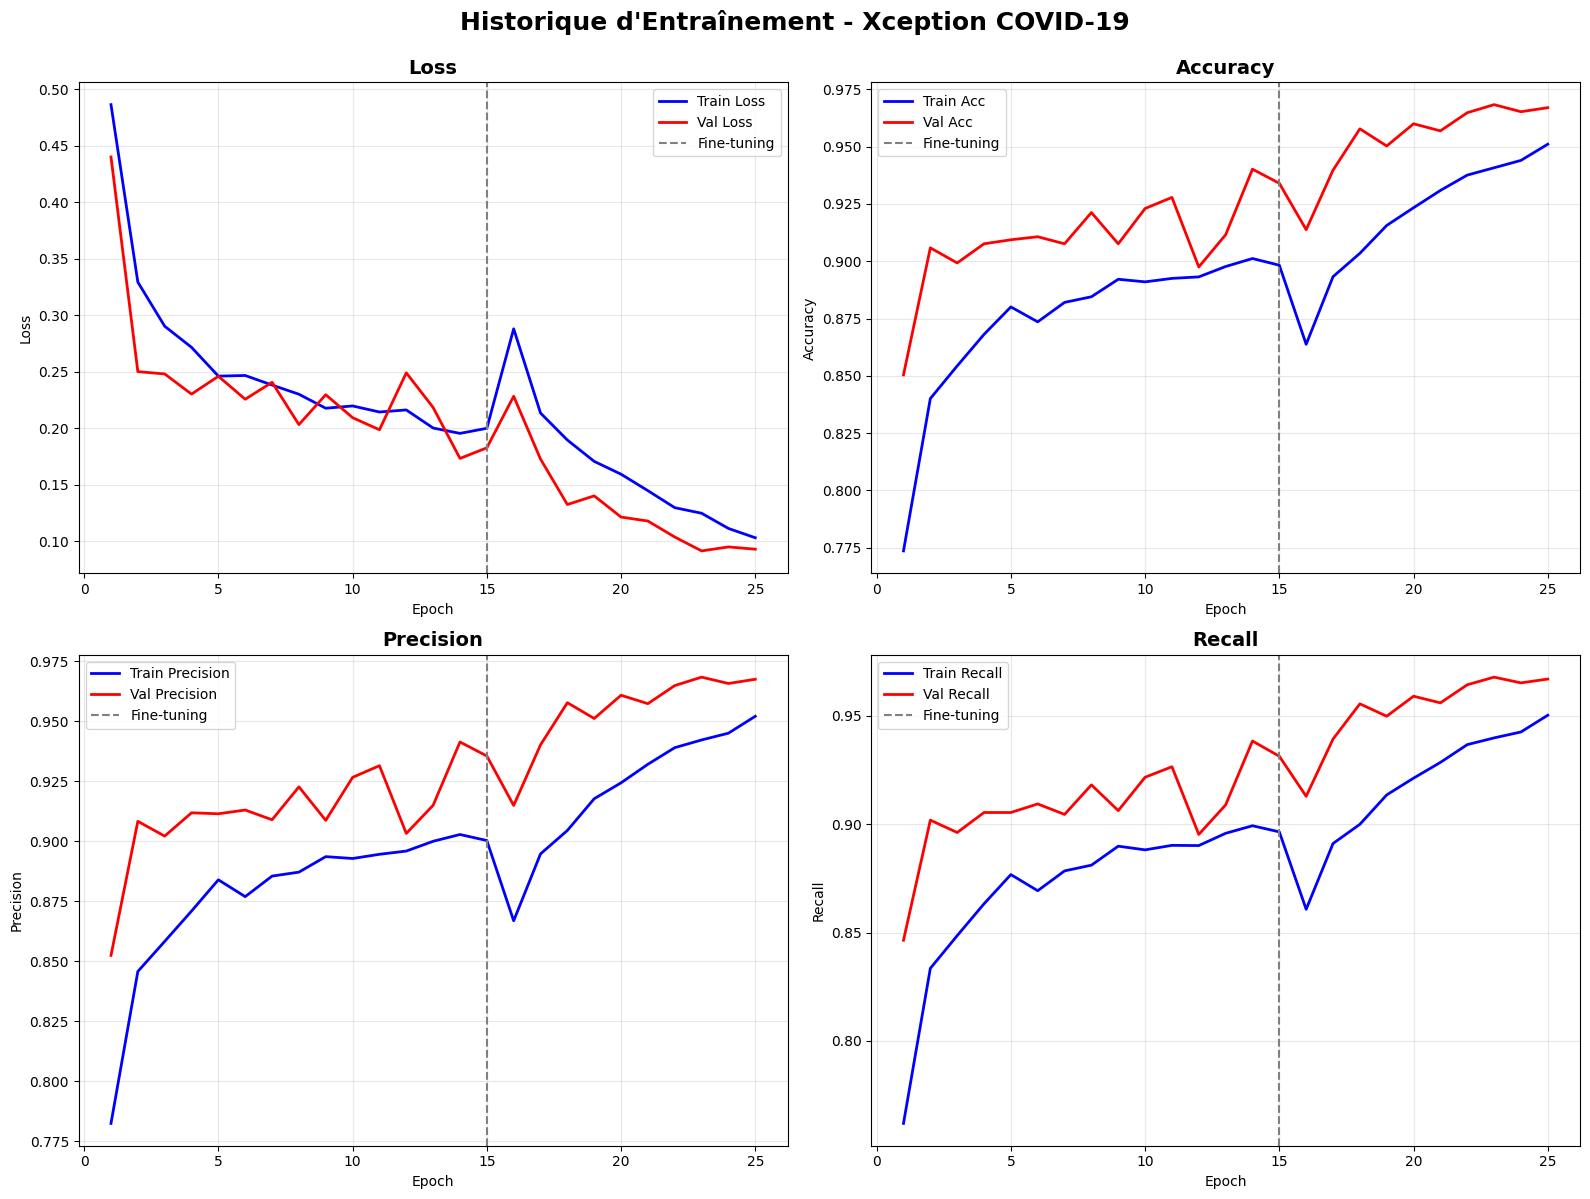

In [17]:
# Fusion des historiques
history_combined = {
    'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
    'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss'],
    'accuracy': history_phase1.history['accuracy'] + history_phase2.history['accuracy'],
    'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
    'precision': history_phase1.history['precision'] + history_phase2.history['precision'],
    'val_precision': history_phase1.history['val_precision'] + history_phase2.history['val_precision'],
    'recall': history_phase1.history['recall'] + history_phase2.history['recall'],
    'val_recall': history_phase1.history['val_recall'] + history_phase2.history['val_recall']
}

# Fonction de visualisation
def plot_training_history(history, phase1_epochs):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Historique d\'Entraînement - Xception COVID-19',
                 fontsize=18, fontweight='bold', y=0.995)

    epochs = range(1, len(history['loss']) + 1)

    # Loss
    axes[0, 0].plot(epochs, history['loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].axvline(x=phase1_epochs, color='gray', linestyle='--',
                       label='Fine-tuning', linewidth=1.5)
    axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Accuracy
    axes[0, 1].plot(epochs, history['accuracy'], 'b-', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs, history['val_accuracy'], 'r-', label='Val Acc', linewidth=2)
    axes[0, 1].axvline(x=phase1_epochs, color='gray', linestyle='--',
                       label='Fine-tuning', linewidth=1.5)
    axes[0, 1].set_title('Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Precision
    axes[1, 0].plot(epochs, history['precision'], 'b-', label='Train Precision', linewidth=2)
    axes[1, 0].plot(epochs, history['val_precision'], 'r-', label='Val Precision', linewidth=2)
    axes[1, 0].axvline(x=phase1_epochs, color='gray', linestyle='--',
                       label='Fine-tuning', linewidth=1.5)
    axes[1, 0].set_title('Precision', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Recall
    axes[1, 1].plot(epochs, history['recall'], 'b-', label='Train Recall', linewidth=2)
    axes[1, 1].plot(epochs, history['val_recall'], 'r-', label='Val Recall', linewidth=2)
    axes[1, 1].axvline(x=phase1_epochs, color='gray', linestyle='--',
                       label='Fine-tuning', linewidth=1.5)
    axes[1, 1].set_title('Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Affichage
plot_training_history(history_combined, EPOCHS_PHASE1)

## **Étape 10 : Évaluation sur l'Ensemble de Test**

### **10.1 Prédictions et Métriques Globales**

In [18]:
# Chargement du meilleur modèle
best_model = keras.models.load_model('best_xception_model.keras')

# Évaluation sur l'ensemble de test
print("Évaluation sur l'ensemble de test...")
test_loss, test_acc, test_prec, test_rec = best_model.evaluate(test_generator, verbose=1)

# Calcul du F1-Score
test_f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec)

print("\n" + "="*60)
print("RÉSULTATS SUR L'ENSEMBLE DE TEST")
print("="*60)
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print("="*60)

Évaluation sur l'ensemble de test...
72/72 ━━━━━━━━━━━━━━━━━━━━ 49s 510ms/step - accuracy: 0.9555 - loss: 0.1248 - precision: 0.9563 - recall: 0.9555

RÉSULTATS SUR L'ENSEMBLE DE TEST
Loss:      0.0981
Accuracy:  0.9648 (96.48%)
Precision: 0.9657
Recall:    0.9648
F1-Score:  0.9652


### **10.2 Génération des Prédictions**

In [19]:
# Génération des prédictions
print("Génération des prédictions...")
test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Noms des classes
class_names = list(test_generator.class_indices.keys())

print(f"\n✓ Prédictions générées: {len(y_pred)} images")
print(f"✓ Classes: {class_names}")

Génération des prédictions...
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 424ms/step

✓ Prédictions générées: 2274 images
✓ Classes: ['COVID', 'Normal', 'Viral Pneumonia']


## **Étape 11 : Rapport de Classification Détaillé**


RAPPORT DE CLASSIFICATION PAR CLASSE
                 precision    recall  f1-score   support

          COVID     0.9590    0.9484    0.9537       543
         Normal     0.9739    0.9745    0.9742      1529
Viral Pneumonia     0.9130    0.9356    0.9242       202

       accuracy                         0.9648      2274
      macro avg     0.9486    0.9529    0.9507      2274
   weighted avg     0.9649    0.9648    0.9648      2274



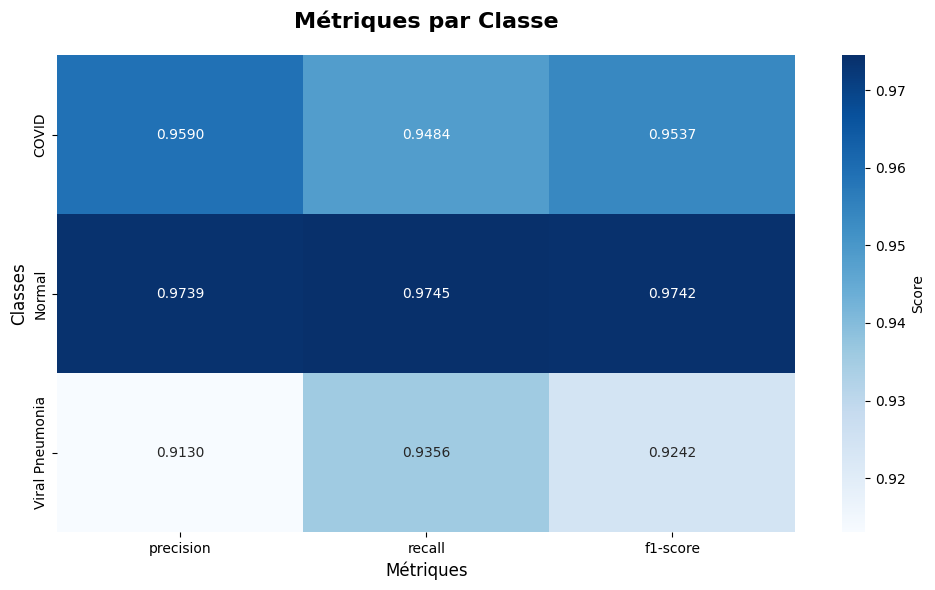

In [20]:
# Rapport de classification
print("\n" + "="*70)
print("RAPPORT DE CLASSIFICATION PAR CLASSE")
print("="*70)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# Création d'un DataFrame pour une meilleure visualisation
report_dict = classification_report(y_true, y_pred, target_names=class_names,
                                    output_dict=True, digits=4)
df_report = pd.DataFrame(report_dict).transpose()

# Visualisation du rapport sous forme de heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_report.iloc[:-3, :3], annot=True, fmt='.4f', cmap='Blues',
            cbar_kws={'label': 'Score'})
plt.title('Métriques par Classe', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Métriques', fontsize=12)
plt.ylabel('Classes', fontsize=12)
plt.tight_layout()
plt.show()

## **Étape 12 : Matrice de Confusion**

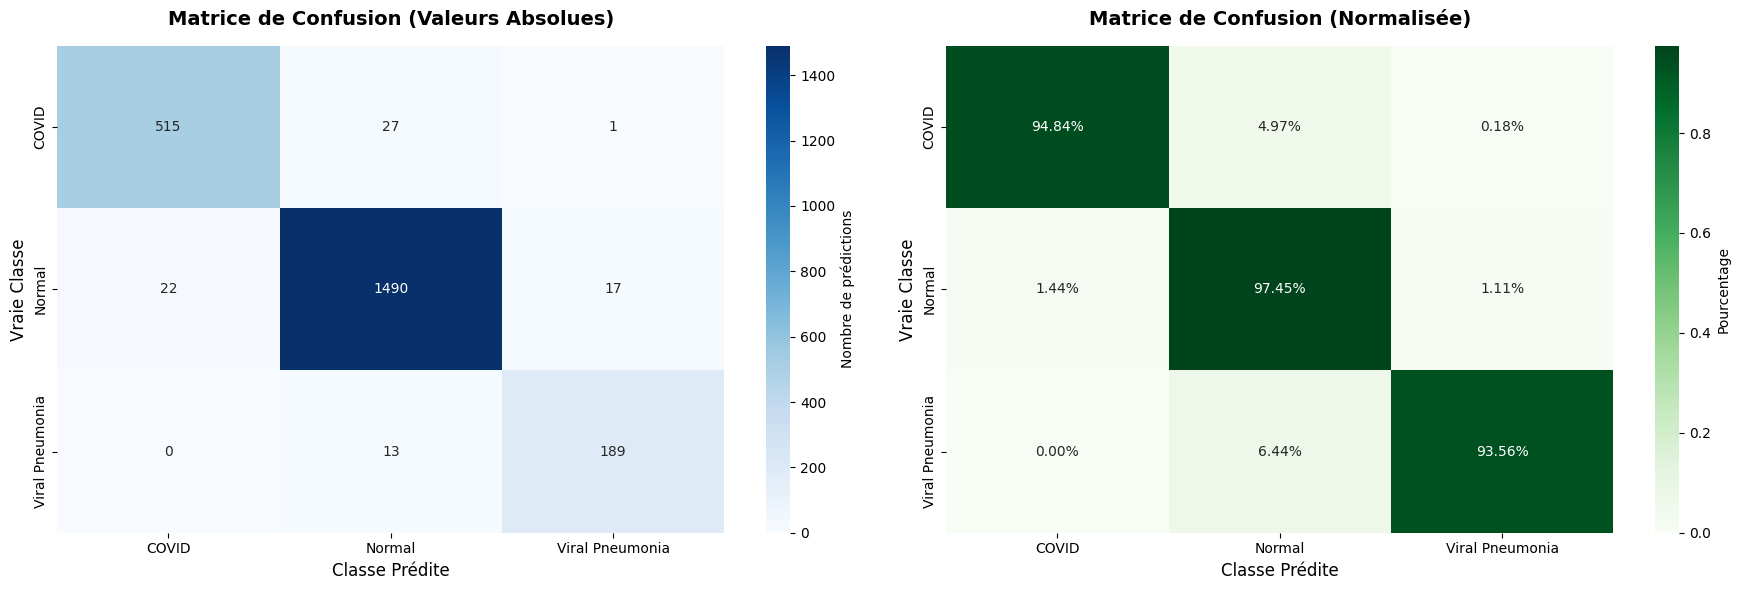


Analyse des erreurs:

COVID:
  • Total: 543
  • Correct: 515 (94.84%)
  • Erreurs: 28
  • Confusions:
    - 27 prédictions comme Normal
    - 1 prédictions comme Viral Pneumonia

Normal:
  • Total: 1529
  • Correct: 1490 (97.45%)
  • Erreurs: 39
  • Confusions:
    - 22 prédictions comme COVID
    - 17 prédictions comme Viral Pneumonia

Viral Pneumonia:
  • Total: 202
  • Correct: 189 (93.56%)
  • Erreurs: 13
  • Confusions:
    - 13 prédictions comme Normal


In [21]:
# Calcul de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Normalisation
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Matrice brute
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Nombre de prédictions'})
axes[0].set_title('Matrice de Confusion (Valeurs Absolues)',
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Vraie Classe', fontsize=12)
axes[0].set_xlabel('Classe Prédite', fontsize=12)

# Matrice normalisée
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Pourcentage'})
axes[1].set_title('Matrice de Confusion (Normalisée)',
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Vraie Classe', fontsize=12)
axes[1].set_xlabel('Classe Prédite', fontsize=12)

plt.tight_layout()
plt.show()

# Analyse des erreurs
print("\nAnalyse des erreurs:")
print("="*60)
for i, class_name in enumerate(class_names):
    total = cm[i].sum()
    correct = cm[i, i]
    errors = total - correct
    accuracy = correct / total * 100

    print(f"\n{class_name}:")
    print(f"  • Total: {total}")
    print(f"  • Correct: {correct} ({accuracy:.2f}%)")
    print(f"  • Erreurs: {errors}")

    if errors > 0:
        print(f"  • Confusions:")
        for j, other_class in enumerate(class_names):
            if i != j and cm[i, j] > 0:
                print(f"    - {cm[i, j]} prédictions comme {other_class}")

## **Étape 13 : Courbes ROC et AUC**

Les courbes ROC permettent d'évaluer la capacité du modèle à discriminer entre les classes.

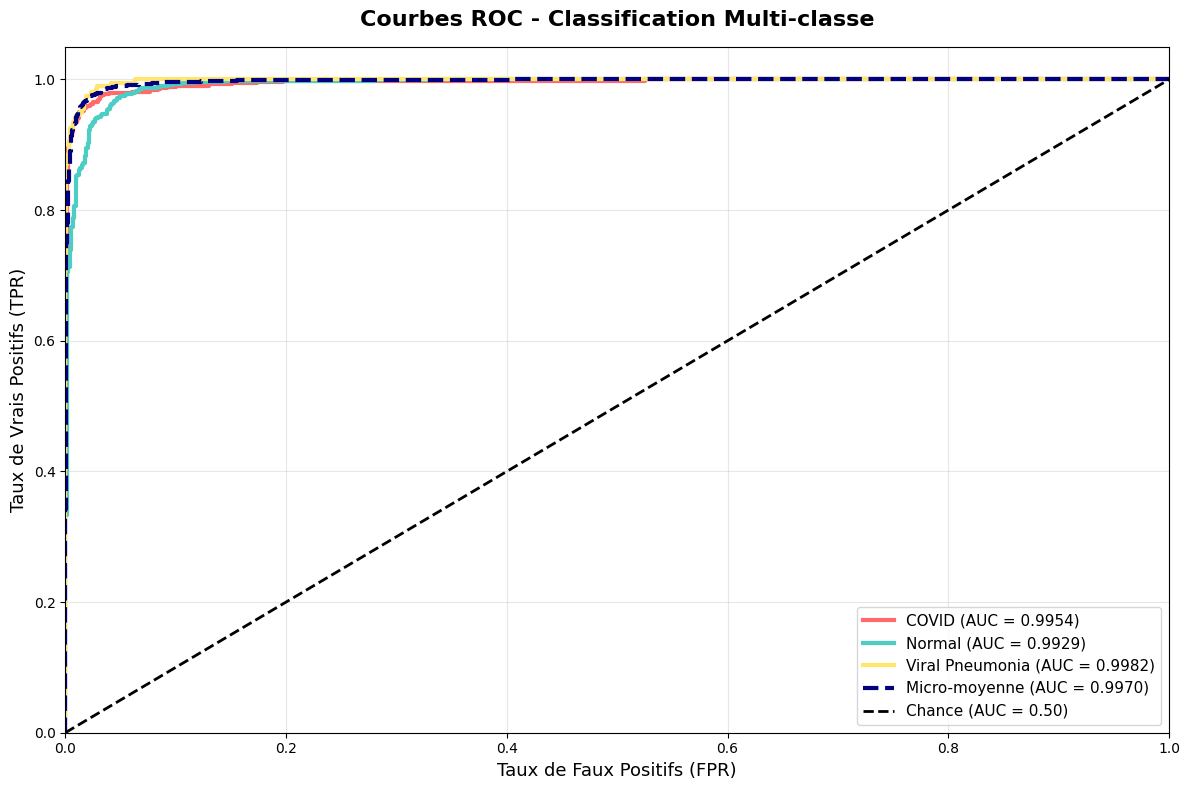


AUC par classe:
COVID               : 0.9954
Normal              : 0.9929
Viral Pneumonia     : 0.9982
Micro-moyenne       : 0.9970


In [22]:
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarisation des labels
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

# Calcul des courbes ROC et AUC pour chaque classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcul de la courbe ROC micro-moyenne
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Visualisation
plt.figure(figsize=(12, 8))
colors = cycle(['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=3,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot(fpr["micro"], tpr["micro"], color='navy', lw=3, linestyle='--',
         label=f'Micro-moyenne (AUC = {roc_auc["micro"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=13)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=13)
plt.title('Courbes ROC - Classification Multi-classe', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Affichage des AUC
print("\nAUC par classe:")
print("="*50)
for i, class_name in enumerate(class_names):
    print(f"{class_name:20s}: {roc_auc[i]:.4f}")
print(f"{'Micro-moyenne':20s}: {roc_auc['micro']:.4f}")
print("="*50)

## **Étape 14 : Visualisation des Prédictions**

Affichons quelques exemples de prédictions correctes et incorrectes.

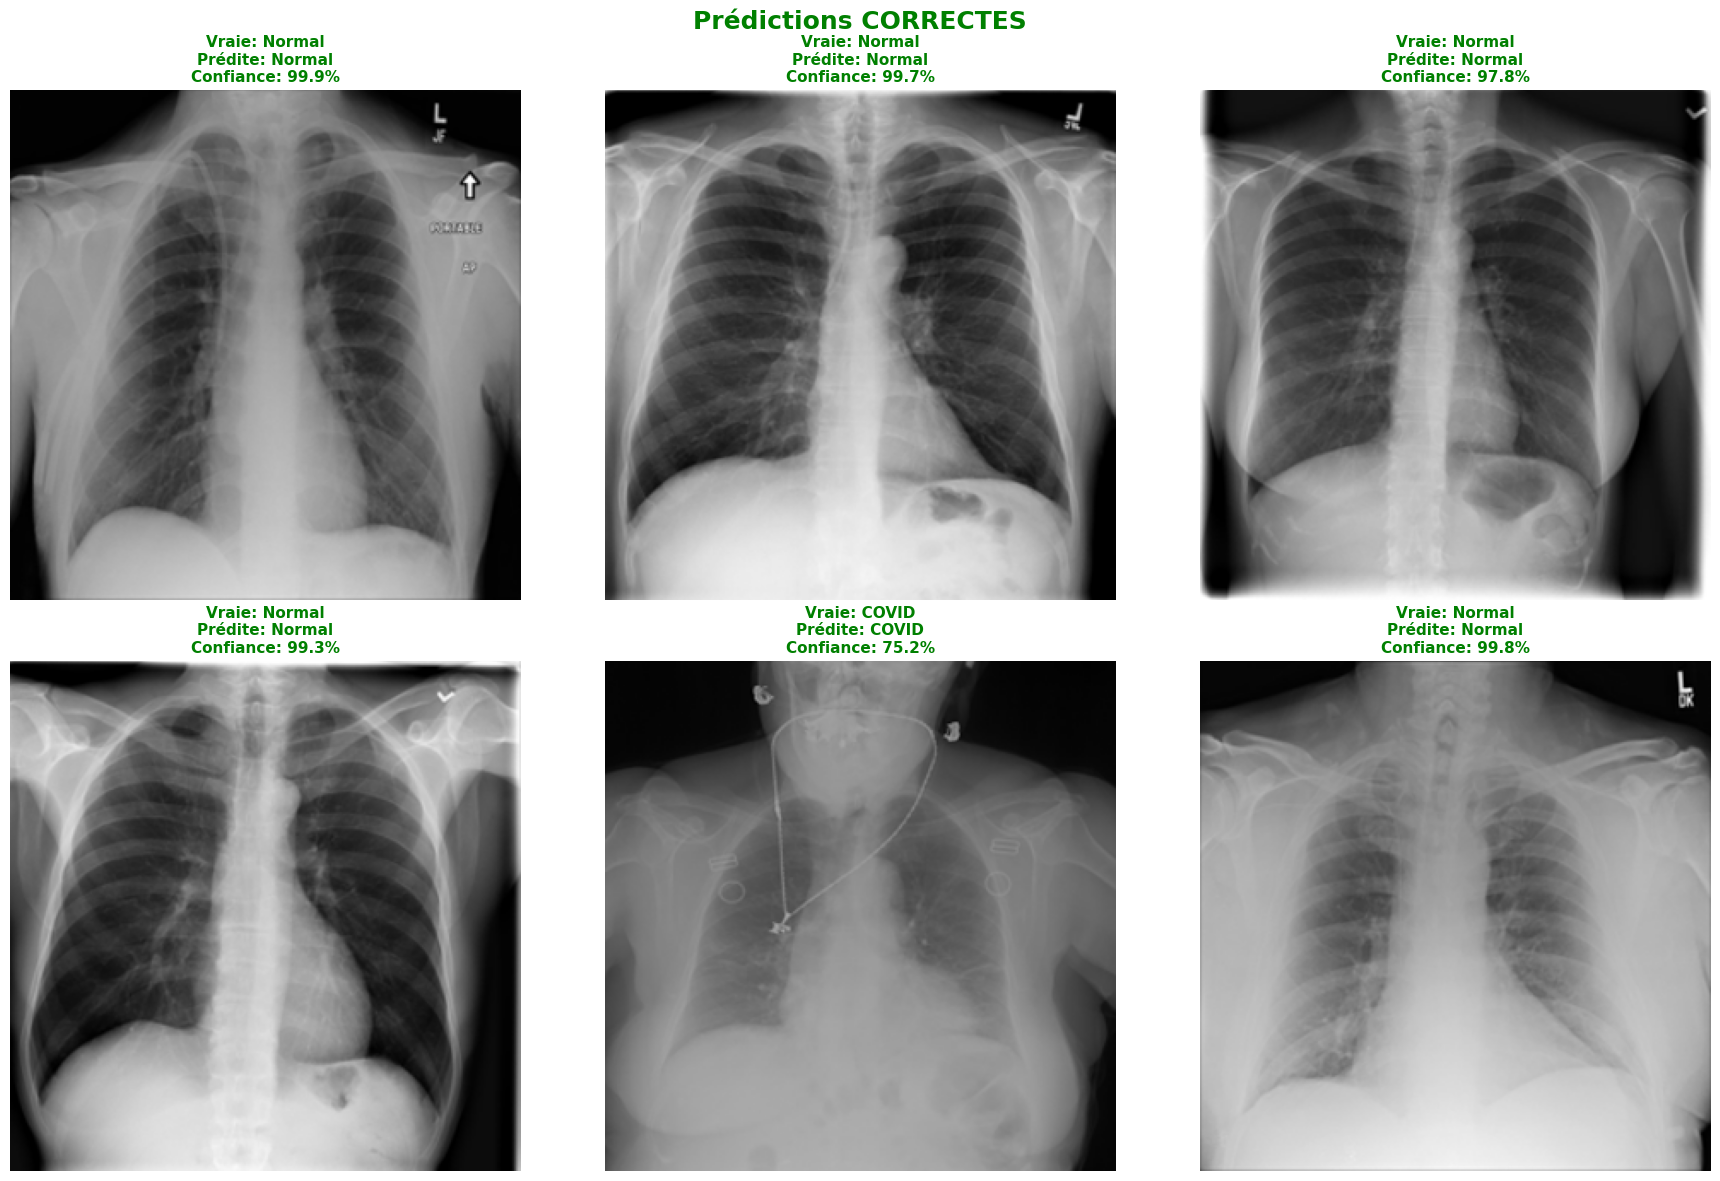

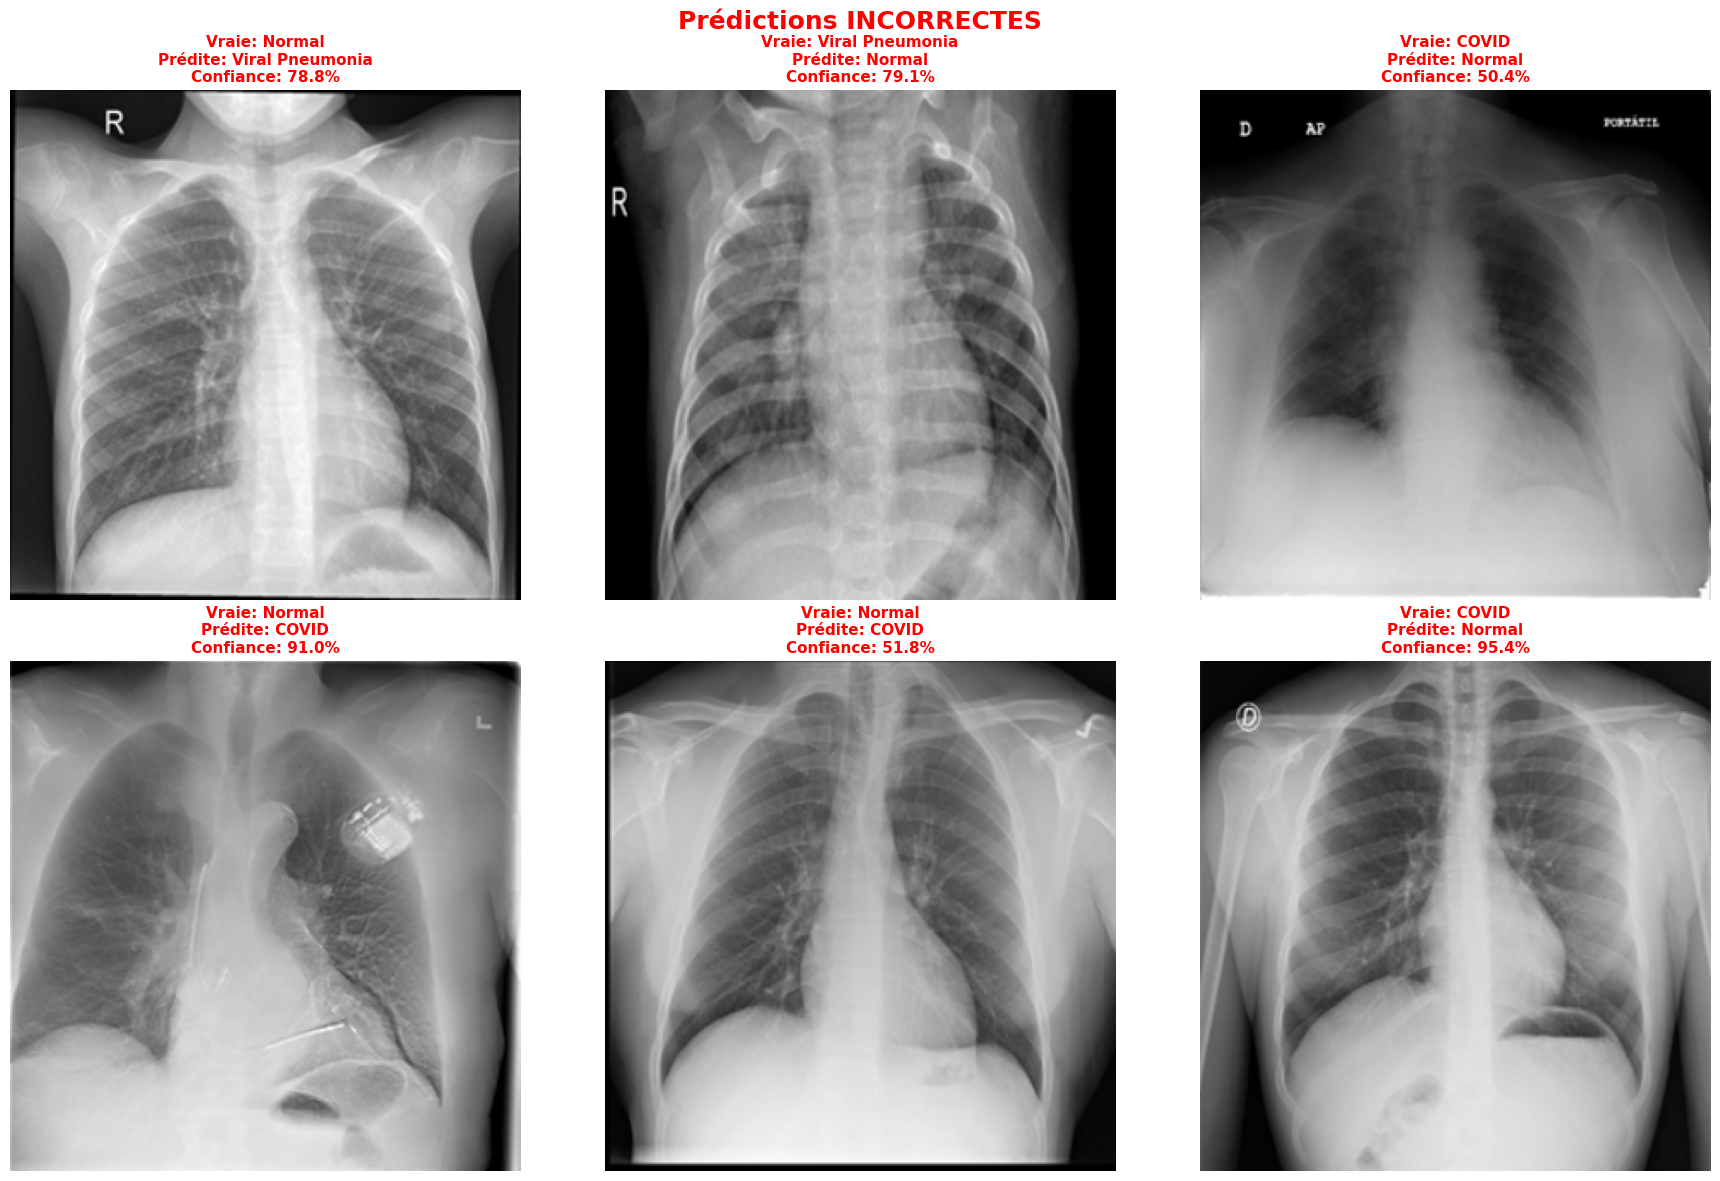

In [23]:
def visualize_predictions(generator, predictions, true_labels, class_names,
                          num_correct=6, num_incorrect=6):
    """
    Visualise les prédictions correctes et incorrectes
    """
    # Indices des prédictions correctes et incorrectes
    correct_idx = np.where(predictions == true_labels)[0]
    incorrect_idx = np.where(predictions != true_labels)[0]

    # Sélection aléatoire
    selected_correct = np.random.choice(correct_idx, min(num_correct, len(correct_idx)),
                                        replace=False)
    selected_incorrect = np.random.choice(incorrect_idx, min(num_incorrect, len(incorrect_idx)),
                                          replace=False)

    # Récupération des images
    def get_images(indices, generator):
        images = []
        for idx in indices:
            img_path = generator.filepaths[idx]
            img = load_img(img_path, target_size=(299, 299))
            images.append(img)
        return images

    correct_images = get_images(selected_correct, generator)
    incorrect_images = get_images(selected_incorrect, generator)

    # Visualisation des prédictions correctes
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Prédictions CORRECTES', fontsize=18, fontweight='bold',
                 color='green', y=0.98)

    for i, (img, idx) in enumerate(zip(correct_images, selected_correct)):
        row, col = i // 3, i % 3
        axes[row, col].imshow(img)
        axes[row, col].axis('off')

        true_class = class_names[true_labels[idx]]
        pred_class = class_names[predictions[idx]]
        confidence = y_pred_probs[idx][predictions[idx]] * 100

        title = f'Vraie: {true_class}\nPrédite: {pred_class}\nConfiance: {confidence:.1f}%'
        axes[row, col].set_title(title, fontsize=11, fontweight='bold', color='green')

    plt.tight_layout()
    plt.show()

    # Visualisation des prédictions incorrectes
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Prédictions INCORRECTES', fontsize=18, fontweight='bold',
                 color='red', y=0.98)

    for i, (img, idx) in enumerate(zip(incorrect_images, selected_incorrect)):
        row, col = i // 3, i % 3
        axes[row, col].imshow(img)
        axes[row, col].axis('off')

        true_class = class_names[true_labels[idx]]
        pred_class = class_names[predictions[idx]]
        confidence = y_pred_probs[idx][predictions[idx]] * 100

        title = f'Vraie: {true_class}\nPrédite: {pred_class}\nConfiance: {confidence:.1f}%'
        axes[row, col].set_title(title, fontsize=11, fontweight='bold', color='red')

    plt.tight_layout()
    plt.show()

# Affichage
visualize_predictions(test_generator, y_pred, y_true, class_names)

## **Étape 15 : Analyse de la Confiance des Prédictions**

Analyse de la confiance des prédictions:
Confiance moyenne (toutes):     0.9557
Confiance moyenne (correctes):  0.9637
Confiance moyenne (incorrectes): 0.7357


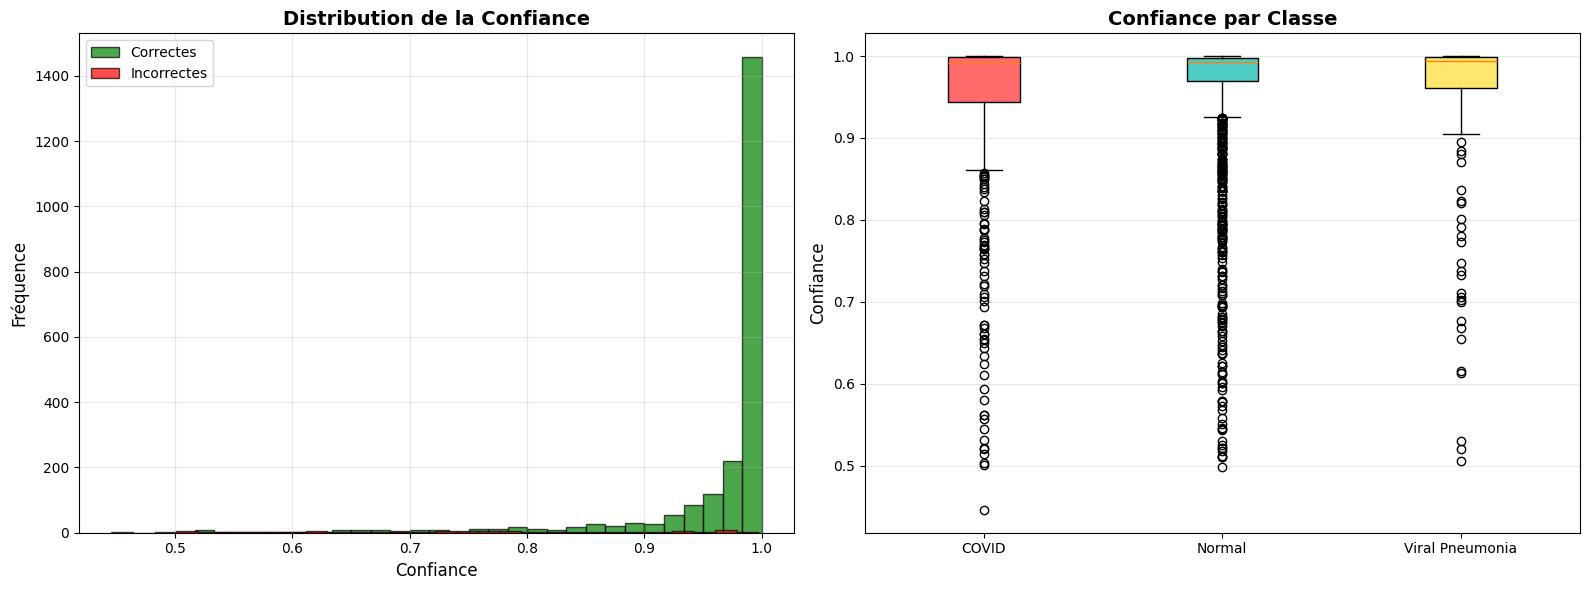

In [24]:
# Extraction des confiances maximales
confidences = np.max(y_pred_probs, axis=1)
correct_mask = (y_pred == y_true)

# Statistiques
print("Analyse de la confiance des prédictions:")
print("="*60)
print(f"Confiance moyenne (toutes):     {confidences.mean():.4f}")
print(f"Confiance moyenne (correctes):  {confidences[correct_mask].mean():.4f}")
print(f"Confiance moyenne (incorrectes): {confidences[~correct_mask].mean():.4f}")
print("="*60)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogramme des confiances
axes[0].hist(confidences[correct_mask], bins=30, alpha=0.7, label='Correctes',
             color='green', edgecolor='black')
axes[0].hist(confidences[~correct_mask], bins=30, alpha=0.7, label='Incorrectes',
             color='red', edgecolor='black')
axes[0].set_xlabel('Confiance', fontsize=12)
axes[0].set_ylabel('Fréquence', fontsize=12)
axes[0].set_title('Distribution de la Confiance', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot par classe
confidence_by_class = [confidences[y_true == i] for i in range(len(class_names))]
bp = axes[1].boxplot(confidence_by_class, labels=class_names, patch_artist=True)
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_ylabel('Confiance', fontsize=12)
axes[1].set_title('Confiance par Classe', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## **Étape 16 : Sauvegarde des Résultats**

Sauvegardons tous les résultats et le modèle final.

In [25]:
import json
from datetime import datetime

# Création du dossier de résultats
results_dir = './results'
os.makedirs(results_dir, exist_ok=True)

# 1. Sauvegarde du modèle final
model_path = os.path.join(results_dir, 'xception_covid19_final.keras')
best_model.save(model_path)
print(f"✓ Modèle sauvegardé: {model_path}")

# 2. Sauvegarde des résultats sous format JSON
results = {
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model': 'Xception',
    'dataset': 'COVID-19 Radiography Database',
    'classes': class_names,
    'training': {
        'epochs_phase1': EPOCHS_PHASE1,
        'epochs_phase2': EPOCHS_PHASE2,
        'batch_size': BATCH_SIZE,
        'initial_lr': INITIAL_LR,
        'fine_tune_lr': FINE_TUNE_LR
    },
    'test_metrics': {
        'accuracy': float(test_acc),
        'precision': float(test_prec),
        'recall': float(test_rec),
        'f1_score': float(test_f1),
        'loss': float(test_loss)
    },
    'auc_scores': {class_names[i]: float(roc_auc[i]) for i in range(len(class_names))},
    'confusion_matrix': cm.tolist(),
    'class_report': report_dict
}

results_path = os.path.join(results_dir, 'results.json')
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=4, ensure_ascii=False)
print(f"✓ Résultats sauvegardés: {results_path}")

# 3. Sauvegarde de l'historique d'entraînement
history_df = pd.DataFrame(history_combined)
history_path = os.path.join(results_dir, 'training_history.csv')
history_df.to_csv(history_path, index=False)
print(f"✓ Historique sauvegardé: {history_path}")

# 4. Sauvegarde du rapport de classification
report_path = os.path.join(results_dir, 'classification_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("=" * 70 + "\n")
    f.write("RAPPORT DE CLASSIFICATION - Xception COVID-19\n")
    f.write("=" * 70 + "\n\n")
    f.write(report)
print(f"✓ Rapport sauvegardé: {report_path}")

print("\n" + "="*60)
print("✓ Tous les résultats ont été sauvegardés avec succès!")
print("="*60)

✓ Modèle sauvegardé: ./results/xception_covid19_final.keras
✓ Résultats sauvegardés: ./results/results.json
✓ Historique sauvegardé: ./results/training_history.csv
✓ Rapport sauvegardé: ./results/classification_report.txt

✓ Tous les résultats ont été sauvegardés avec succès!


## **Conclusion et Perspectives**

### **Résumé des Résultats**

Dans ce projet, nous avons :
1. Construit un modèle de classification multi-classe avec Xception
2. Géré un dataset déséquilibré avec des poids de classe
3. Appliqué des techniques d'augmentation de données
4. Réalisé un fine-tuning en deux phases
5. Évalué le modèle avec des métriques médicales appropriées

### **Points Forts**
-  **Haute précision** sur la classification des radiographies
- **Bon recall** pour la classe COVID-19 (critique pour le diagnostic)
-  **Visualisations détaillées** pour l'interprétation
-  **Robustesse** grâce à l'augmentation de données

### **Applications Médicales**
Ce modèle peut être utilisé comme :
- **Outil de pré-screening** dans les hôpitaux
- **Application mobile** pour diagnostic rapide
- **Aide dans les régions** avec pénurie de radiologues

---

### * Avertissement Médical**

Ce modèle est un **outil d'aide à la décision** et ne doit pas remplacer l'expertise médicale.
Toute décision diagnostique finale doit être prise par un professionnel de santé qualifié.

---

**Auteurs :** Keita Hadiatou & Rouchdi Asmaa  
**Date :** Novembre 2025  
**Cours :** Intelligence Artificielle - Vision par Ordinateur
